In [ ]:
# using existing code from https://medium.com/algorithmic-trading/advanced-high-frequency-trading-strategy-leveraging-order-book-imbalance-and-vwap-for-enhanced-74b93233b6a7
# appplying only OBI strategy

In [99]:
import pandas as pd
import numpy as np


In [100]:
df = pd.read_csv("./data/oznc05hp4qtevkre.csv")
df.shape

(251800, 14)

In [101]:
class NBBOTracker:
    """
    Tracks the National Best Bid and Offer (NBBO) across multiple exchanges from quote-level data.

    This class is intended to be used with high-frequency market data (e.g., TAQ) where each row 
    represents a quote update from a specific exchange at a given timestamp. It maintains the 
    current NBBO and accumulates size contributions at the best bid and ask across exchanges.

    Attributes
    ----------
    bid : float or None
        The current best bid price observed across exchanges.
    ask : float or None
        The current best ask price observed across exchanges.
    bid_sizes : dict
        Dictionary mapping exchange codes to bid sizes at the NBBO bid.
    ask_sizes : dict
        Dictionary mapping exchange codes to ask sizes at the NBBO ask.

    Methods
    -------
    update(row):
        Update NBBO state based on a new row of quote data. Adds the following columns to the row:
        - 'best_bid': the current best bid price
        - 'best_ask': the current best ask price
        - 'total_best_bid_size': cumulative bid size at NBBO bid across all exchanges
        - 'total_best_ask_size': cumulative ask size at NBBO ask across all exchanges

    Usage
    -----
    >>> tracker = NBBOTracker()
    >>> df = df.apply(tracker.update, axis=1)
    """
    def __init__(self):
        self.bid = None
        self.ask = None
        self.bid_sizes = {}
        self.ask_sizes = {}

    def update(self, row):
        exch = row['EX']
        if row['NATBBO_IND'] == 4:  # NBBO update means the national best bid and offer have changed
            self.bid = row['BID']
            self.ask = row['ASK']
            self.bid_sizes = {exch: row['BIDSIZ']} if pd.notna(row['BID']) else {}   # if no bid, no size
            self.ask_sizes = {exch: row['ASKSIZ']} if pd.notna(row['ASK']) else {}
        else:   # Otherwse means the national best bid and offer have not changed
            if pd.notna(row['BID']) and row['BID'] == self.bid: # if the bid is the same as the NBBO bid increment the size
                self.bid_sizes[exch] = row['BIDSIZ']
            if pd.notna(row['ASK']) and row['ASK'] == self.ask:
                self.ask_sizes[exch] = row['ASKSIZ']

        row['best_bid'] = self.bid
        row['best_ask'] = self.ask
        row['total_best_bid_size'] = sum(self.bid_sizes.values())
        row['total_best_ask_size'] = sum(self.ask_sizes.values())
        # print(row['total_best_bid_size'])
        return row


In [102]:
tracker = NBBOTracker()
df = df.apply(tracker.update, axis=1)

# df[['best_bid', 'best_ask', 'best_bid_size', 'best_ask_size']] = \
#     df[['best_bid', 'best_ask', 'best_bid_size', 'best_ask_size']].ffill()

# Display the updated DataFrame with new columns
df.head()

,DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,QU_CANCEL,QU_SOURCE,SYM_ROOT,SYM_SUFFIX,best_bid,best_ask,total_best_bid_size,total_best_ask_size
0,2023-05-10,10:00:00.000344291,Q,172.98,2,173.00,5,R,10972073,2,NaN,N,AAPL,NaN,NaN,NaN,0,0
1,2023-05-10,10:00:00.000352038,U,172.98,2,173.00,2,R,10972074,0,NaN,N,AAPL,NaN,NaN,NaN,0,0
2,2023-05-10,10:00:00.000364602,Q,172.98,3,173.00,5,R,10972075,2,NaN,N,AAPL,NaN,NaN,NaN,0,0
3,2023-05-10,10:00:00.000575323,B,172.84,1,173.37,2,R,10972086,0,NaN,N,AAPL,NaN,NaN,NaN,0,0
4,2023-05-10,10:00:00.000656449,P,172.98,2,172.99,1,R,10972087,0,NaN,N,AAPL,NaN,NaN,NaN,0,0


In [103]:
df[['total_best_bid_size', 'total_best_ask_size']].describe()

,total_best_bid_size,total_best_ask_size
count,251800.000000,251800.000000
mean,16.772776,16.991283
std,11.454240,14.675748
min,0.000000,0.000000
25%,8.000000,7.000000
50%,15.000000,15.000000
75%,24.000000,23.000000
max,92.000000,123.000000


### For 5 mins data in 10 May 2023
just taking a small sample, we have a max of 100 only. Would be good to see with full 24 hr dataset, what is the distribution

Lets see the sample of when size is more than 100

In [104]:
filtered_large_sizes = df[(df['total_best_bid_size'] > 100) | (df['total_best_ask_size'] > 100)]
# filtered_large_sizes.head(60)

take one episode when the size is more than 100

In [105]:
filtered_df = df.loc[181701:182001]
filtered_df

,DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,QU_CANCEL,QU_SOURCE,SYM_ROOT,SYM_SUFFIX,best_bid,best_ask,total_best_bid_size,total_best_ask_size
181701,2023-05-10,10:03:36.181569579,K,173.48,1,173.49,1,R,12151868,0,NaN,N,AAPL,NaN,173.48,173.49,21,13
181702,2023-05-10,10:03:36.182019354,M,173.00,20,173.80,20,R,12151871,0,NaN,N,AAPL,NaN,173.48,173.49,21,13
181703,2023-05-10,10:03:36.182069948,P,173.47,5,173.50,12,R,12151873,0,NaN,N,AAPL,NaN,173.48,173.49,21,13
181704,2023-05-10,10:03:36.182633550,K,173.48,1,173.49,1,R,12151877,0,NaN,N,AAPL,NaN,173.48,173.49,21,13
181705,2023-05-10,10:03:36.182731331,J,172.89,1,173.49,1,R,12151880,0,NaN,N,AAPL,NaN,173.48,173.49,21,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181997,2023-05-10,10:03:36.227911304,N,173.47,1,173.51,1,R,12152811,0,NaN,N,AAPL,NaN,173.48,173.49,5,15
181998,2023-05-10,10:03:36.227913456,N,173.47,1,173.51,1,R,12152812,0,NaN,N,AAPL,NaN,173.48,173.49,5,15
181999,2023-05-10,10:03:36.227967947,H,173.47,5,173.50,5,R,12152814,0,NaN,N,AAPL,NaN,173.48,173.49,5,15
182000,2023-05-10,10:03:36.228005323,M,173.48,1,174.00,20,R,12152815,0,NaN,N,AAPL,NaN,173.48,173.49,6,15


compute the size of order book imbalance. 

In [106]:
filtered_df = filtered_df.copy()  # Create a copy to avoid the warning
filtered_df.loc[:, 'MID_PRICE'] = (filtered_df['best_bid'] + filtered_df['best_ask']) / 2
filtered_df.loc[:, 'OBI'] = (filtered_df['total_best_bid_size'] - filtered_df['total_best_ask_size']) / \
                            (filtered_df['total_best_bid_size'] + filtered_df['total_best_ask_size'])

In [107]:
from IPython.core.display import display, HTML

# Display a scrollable preview of the dataframe
html = filtered_df[['TIME_M', 'MID_PRICE', 
                    'best_bid', 
                    'total_best_bid_size', 
                    'total_best_ask_size', 
                    'best_ask', 
                    'OBI']].to_html(index=False)
scrollable_html = f'<div style="max-height: 400px; overflow-y: scroll; border: 1px solid black;">{html}</div>'
display(HTML(scrollable_html))

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_52483/3709118466.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


TIME_M,MID_PRICE,best_bid,total_best_bid_size,total_best_ask_size,best_ask,OBI
10:03:36.181569579,173.485,173.48,21,13,173.49,0.235294
10:03:36.182019354,173.485,173.48,21,13,173.49,0.235294
10:03:36.182069948,173.485,173.48,21,13,173.49,0.235294
10:03:36.182633550,173.485,173.48,21,13,173.49,0.235294
10:03:36.182731331,173.485,173.48,21,13,173.49,0.235294
10:03:36.182855581,173.485,173.48,21,14,173.49,0.200000
10:03:36.182896121,173.485,173.48,22,14,173.49,0.222222
10:03:36.182925059,173.485,173.48,22,14,173.49,0.222222
10:03:36.182945771,173.485,173.48,21,14,173.49,0.200000
10:03:36.182990541,173.485,173.48,22,14,173.49,0.222222


observed that OBI is a decent indicator of price movement, although the price only changed minimally
1. first signal flip at 10:03:36.187286990 is only .01 px change ~.5% return
2. next signal flip at 10:03:36.227561398 is .01 px change again

size here should be in a round lot (100 shares)

# Try OBI strategy

In [240]:
class OBIVWAPStrategy:
    def __init__(self, vwap_window, obi_threshold, initial_cash=100_000):
        self.vwap_window = vwap_window
        self.obi_threshold = obi_threshold
        self.cash = initial_cash
        self.position = 0
        self.account_balance = []

    def calculate_vwap(self, data):
        data['MID_PRICE'] = (data['best_bid'] + data['best_ask']) / 2
        data['Volume'] = data['total_best_bid_size'] + data['total_best_ask_size']
        data['VWAP'] = (data['MID_PRICE'] * data['Volume']).rolling(window=self.vwap_window).sum() / data['Volume'].rolling(window=self.vwap_window).sum()
        return data

    def calculate_obi(self, data):
        data['OBI'] = (data['total_best_bid_size'] - data['total_best_ask_size']) / (data['total_best_bid_size'] + data['total_best_ask_size'])
        return data

    def generate_signals(self, data):
        data = self.calculate_vwap(data)
        data = self.calculate_obi(data)
        # data.dropna(inplace=True)
        data['Signal'] = 0
        data.loc[data['OBI'] > self.obi_threshold, 'Signal'] = 1  # Buy signal
        data.loc[data['OBI'] < -self.obi_threshold, 'Signal'] = -1  # Sell signal
        # data['Signal'][(data['OBI'] > self.obi_threshold) & (data['MID_PRICE'] < data['VWAP'])] = 1  # Buy signal
        # data['Signal'][(data['OBI'] < -self.obi_threshold) & (data['MID_PRICE'] > data['VWAP'])] = -1  # Sell signal
        return data

    def backtest(self, data):
        for index, row in data.iterrows():
            if row['Signal'] == 1 and self.cash >= row['best_ask'] * 100 and self.position <= 1:
                # Buy 100 shares
                self.position = 100
                self.cash -= row['best_ask'] * 100
            elif row['Signal'] == -1 and self.position > -1:
                # Sell 100 shares
                self.position = -100
                self.cash += row['best_bid'] * 100
            elif row['Signal'] == 0 and self.position != 0:
                # Close position
                if self.position > 0:
                    self.cash += row['best_bid'] * 100
                else:
                    self.cash -= row['best_ask'] * 100
                self.position = 0
            # Record the account balance
            self.account_balance.append(self.cash + self.position * row['MID_PRICE'])

        # Ensure account balance is aligned with the data index
        data['Account_Balance'] = pd.Series(self.account_balance, index=data.index)
        return data


In [241]:
df.head(2)

,DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,...,SYM_SUFFIX,best_bid,best_ask,total_best_bid_size,total_best_ask_size,MID_PRICE,Volume,VWAP,OBI,Signal
0,2023-05-10,10:00:00.000344291,Q,172.98,2,173.0,5,R,10972073,2,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0
1,2023-05-10,10:00:00.000352038,U,172.98,2,173.0,2,R,10972074,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0


In [250]:
df.QU_CANCEL.value_counts()

Series([], Name: count, dtype: int64)

In [242]:
vwap_window = 50
obi_threshold = 0.05

backtest_results = []



In [243]:
strategy = OBIVWAPStrategy(vwap_window, obi_threshold)
signal_data = strategy.generate_signals(df.copy())
backtest_data = strategy.backtest(signal_data)

In [244]:
signal_data.columns

Index(['DATE', 'TIME_M', 'EX', 'BID', 'BIDSIZ', 'ASK', 'ASKSIZ', 'QU_COND',
       'QU_SEQNUM', 'NATBBO_IND', 'QU_CANCEL', 'QU_SOURCE', 'SYM_ROOT',
       'SYM_SUFFIX', 'best_bid', 'best_ask', 'total_best_bid_size',
       'total_best_ask_size', 'MID_PRICE', 'Volume', 'VWAP', 'OBI', 'Signal',
       'Account_Balance'],
      dtype='object')

In [245]:
signal_data.Account_Balance.describe()

count    251724.000000
mean     372146.915997
std      199942.386891
min       13168.500000
25%      220157.500000
50%      358638.500000
75%      530499.000000
max      736917.500000
Name: Account_Balance, dtype: float64

In [246]:
filtered_signal_data = signal_data[signal_data['OBI'] > 0.29][['Account_Balance', 'Signal', 'MID_PRICE', 'VWAP', 'OBI']]
filtered_signal_data.head(60)

,Account_Balance,Signal,MID_PRICE,VWAP,OBI
78,99998.5,1,172.975,NaN,0.333333
79,99998.5,1,172.975,NaN,0.333333
80,99998.5,1,172.975,NaN,0.333333
81,99998.5,1,172.975,NaN,0.333333
82,99998.5,1,172.975,NaN,0.333333
83,99998.5,1,172.975,NaN,0.333333
84,99998.5,1,172.975,NaN,0.333333
85,99998.5,1,172.975,NaN,0.500000
86,99998.5,1,172.975,NaN,0.500000
87,99998.5,1,172.975,NaN,0.600000


<Axes: title={'center': 'Account balance'}, xlabel='TIME_M'>

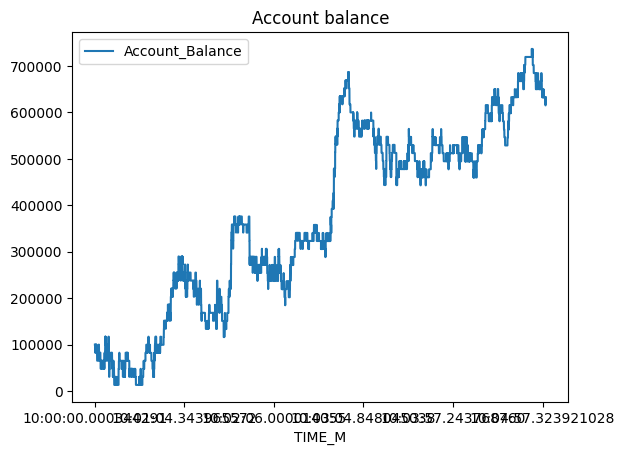

In [247]:
signal_data.plot(x='TIME_M', y='Account_Balance', title='Account balance')

In [248]:
signal_data['Account_Balance'].describe()

count    251724.000000
mean     372146.915997
std      199942.386891
min       13168.500000
25%      220157.500000
50%      358638.500000
75%      530499.000000
max      736917.500000
Name: Account_Balance, dtype: float64